DATA LOADING

In [66]:
# Import the libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sb 
import pathlib as pl

In [2]:
# Load the Fairlife dataset
df = pd.read_csv("c:/users/kaustubh/onedrive/desktop/cpg-product-intelligence/datasets/fairlife_from_dump.csv")

In [3]:
df

,code,product_name,brands,categories_tags,countries_tags,packaging_tags,stores,purchase_places,nutriscore_grade,nova_group,ecoscore_grade,ingredients_text,nutriments.sugars_100g,nutriments.energy-kcal_100g
0,256312008627,"Fairlife, Purely Nutritious Milk",Fairlife Llc,NaN,united-states,NaN,NaN,NaN,unknown,NaN,unknown,"Reduced fat filtered milk (high protein, high ...",2.50,50.0
1,811620020169,Whole ultra-filtered milk,fairlife,"beverages-and-beverages-preparations, beverage...",united-states,NaN,NaN,NaN,b,1.0,NaN,"ultra-filtered milk, lactase enzyme, vitamin a...",NaN,NaN
2,811620020398,Chocolate Reduced Fat Ultra-Filtered Milk,fairlife,"beverages-and-beverages-preparations, beverage...",united-states,NaN,NaN,NaN,d,4.0,NaN,"Low fat ultra-filtered milk, sugar, alkalized ...",NaN,NaN
3,811620020404,STRAWBERRY 2% REDUCED FAT ultra-filtered milk,fairlife,"beverages-and-beverages-preparations, beverage...",united-states,NaN,NaN,NaN,d,4.0,NaN,"Low fat ultra-filtered milk, sugar, natural fl...",NaN,NaN
4,811620021012,Rich chocolate nutrition shake with honey & oats,Fairlife Smart Milkshakes,"dairies, milks",united-states,NaN,NaN,NaN,d,4.0,d,"Filtered reduced fat grade a milk, honey, alka...",4.58,71.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
205,11620022118,Chocolate Nutrition Shake,fairlife,NaN,united-states,NaN,NaN,NaN,unknown,NaN,NaN,NaN,NaN,NaN
206,52115783,Core Power Elite Strawberry High Protein Milk ...,fairlife,NaN,united-states,NaN,NaN,NaN,unknown,NaN,NaN,NaN,NaN,NaN
207,1162002065,Core Power High Protein Milk Shake Vanilla,fairlife,NaN,united-states,NaN,NaN,NaN,unknown,NaN,NaN,NaN,NaN,NaN
208,884912002427,Vanilla Cream,fairlife,NaN,united-states,NaN,NaN,NaN,unknown,NaN,NaN,NaN,NaN,NaN


DATA CLEANING

In [4]:
# Inspect the data types of all columns to identify any required conversions.
df.dtypes

code                             int64
product_name                       str
brands                             str
categories_tags                    str
countries_tags                     str
packaging_tags                     str
stores                             str
purchase_places                    str
nutriscore_grade                   str
nova_group                     float64
ecoscore_grade                     str
ingredients_text                   str
nutriments.sugars_100g         float64
nutriments.energy-kcal_100g    float64
dtype: object

In [5]:
# Convert the product code column to float format first cauz values are big.
df=df.astype({"code": "float64"})

In [6]:
# Convert the product code column to integer format.
df=df.astype({"code": "int64"})

In [7]:
# Examine the product code values before converting the column to a numeric type.
df.code.unique()

array([ 256312008627,  811620020169,  811620020398,  811620020404,
        811620021012,  856312002207,  856312002634,  856312002757,
        856312002795,  811620020657,  811620021951,  811620021388,
        811620021784,  811620022118,   72060001327,  811620022125,
        811620020879,  811620020626,  811620020893,  811620021418,
        811620022248,      21160202,  811620020671,  811620021791,
        811620021777,  811620020695,  811620022750,  811620022194,
        811620022132,  811620022149, 6764512002757,  811620022514,
       1818676022740,  852455005778,      22154071,  811620022927,
        811620021739,      81161775,  811620002127,  811620061933,
        811620022996,       4757839, 3818970000350,  351652900447,
       3357934020336,   49000550122,   49000550115,  432976785979,
       1817676021982,  811620022187,      96356340,  671620022118,
        600934020305,  801300020633,  811620020367, 3857960020633,
         49000551365,      18636714,  811620024020,  811620022

In [8]:
# Review the unique brand names to identify inconsistent spellings.
df.brands.unique()

<ArrowStringArray>
[                    'Fairlife Llc',                         'fairlife',
        'Fairlife Smart Milkshakes',     'Fair Oaks Farms Brands  Inc.',
                         'Fairlife',                                nan,
 'fairlife nutrition plan,fairlife',             'Fairlife,Minute Maid',
          'fairlife plan nutrition',                        'Fair life',
                      'Core  Power',               'Fueled By Fairlife',
              'Core Power Fairlife',           'Core Power By Fairlife',
          'fairlife nutrition plan']
Length: 15, dtype: str

In [9]:
# Standardize brand names by correcting inconsistent spellings and capitalization.
# This ensures all variations of the same brand are grouped together.
df.brands = df.brands.replace({
    "Fairlife Llc" : "Fairlife",
    "fairlife" : "Fairlife",
    "Fairlife Smart Milkshakes" : "Fairlife",
    "Fair Oaks Farms Brands  Inc." : "Fairlife",
    " nan" : "Fairlife",
    "fairlife nutrition plan,fairlife" : "Fairlife",
    "Fairlife,Minute Maid" : "Fairlife",
    "fairlife plan nutrition" : "Fairlife",
    "Fair life" : "Fairlife",
    "Core Power Fairlife" : "Fairlife",
    "Core Power By Fairlife" : "Fairlife",
    "fairlife nutrition plan" : "Fairlife"}, regex=True)

In [10]:
# Replace missing brand values with 'Unknown' to avoid null values.
df.brands = df.brands.fillna("unknown")
df.brands.isnull().sum()

np.int64(0)

In [11]:
# Replace missing values in selected categorical columns with 'Unknown'.
cols = [
    "categories_tags",
    "countries_tags",
    "packaging_tags",
    "stores",
    "purchase_places",
    "ecoscore_grade",
    "ingredients_text"
    
    
]

df[cols] = df[cols].fillna("Unknown")

# DATA PREPARATION

In [12]:
# Create a cleaned copy of the dataset.
# All subsequent preprocessing steps are performed on this copy to preserve the original data.
df_clean = df.copy()

In [13]:
# Split multiple country tags into individual rows and standardize
# the text by trimming spaces and converting to lowercase.
country_df = df_clean.copy()
country_df["countries_tags"] = country_df["countries_tags"].str.split(",")
country_df = country_df.explode("countries_tags")
country_df["countries_tags"] = country_df["countries_tags"].str.strip().str.lower()

In [14]:
# Split multiple packaging tags into separate rows and standardize
# the values for accurate packaging analysis.
pack_df = df_clean.copy()
pack_df["packaging_tags"] = pack_df["packaging_tags"].str.split(",")
pack_df = pack_df.explode("packaging_tags")
pack_df["packaging_tags"] = pack_df["packaging_tags"].str.strip().str.lower()

In [15]:
# Split multiple category tags into separate rows and standardize
# the text for consistent category analysis.
cat_df = df_clean.copy()
cat_df["categories_tags"] = cat_df["categories_tags"].str.split(",")
cat_df = cat_df.explode("categories_tags")
cat_df["categories_tags"] = cat_df["categories_tags"].str.strip().str.lower()

In [16]:
# Split multiple store names into individual rows and standardize
# the values for store-level analysis.
store_df = df_clean.copy()
store_df["stores"] = store_df["stores"].str.split(",")
store_df = store_df.explode("stores")
store_df["stores"] = store_df["stores"].str.strip().str.lower()

In [17]:
# Display the frequency of each brand.
df.brands.value_counts()

brands
Fairlife                            184
unknown                              19
Fairlife nutrition plan,Fairlife      2
Fairlife nutrition plan               2
Fairlife plan nutrition               1
Core  Power                           1
Fueled By Fairlife                    1
Name: count, dtype: int64

In [18]:
# Display the number of products available in each country.
country_df.value_counts("countries_tags")

countries_tags
united-states         128
canada                 39
italy                  19
ireland                10
unknown                 3
france                  2
germany                 2
thailand                2
australia               2
south-africa            1
croatia                 1
finland                 1
dominican-republic      1
spain                   1
Name: count, dtype: int64

In [19]:
# Display the frequency of each packaging type.
pack_df.value_counts("packaging_tags")

packaging_tags
unknown                           202
plastic                             7
bottle                              5
pet-polyethylene-terephthalate      1
bottle-or-vial                      1
Name: count, dtype: int64

In [20]:
# Display the frequency of each product category.
cat_df.value_counts("categories_tags")

categories_tags
unknown                                 164
dairies                                  29
dietary-supplements                      24
beverages                                21
bodybuilding-supplements                 21
milks                                    20
protein-shakes                           20
dairy-drinks                             18
beverages-and-beverages-preparations     17
milks-liquid-and-powder                  13
flavoured-milks                          13
chocolate-milks                           7
milkshakes                                5
lactose-free-milk                         2
protein-drink                             2
whole-milks                               1
strawberry-milks                          1
skimmed-milks                             1
protein                                   1
chocolate reduced milk                    1
plastic bottle                            1
semi-skimmed-milks                        1
cow-milks       

In [21]:
# Display the frequency of products available across stores.
store_df.value_counts("stores")

stores
unknown                     207
metro                         2
real canadian superstore      1
urban fare                    1
Name: count, dtype: int64

In [22]:
# Calculate the total number of unique brands.
print("Total Brands :", df["brands"].nunique())

Total Brands : 7


In [23]:
# Calculate the total number of unique categories.
print("Total Categories :", cat_df["categories_tags"].nunique())

Total Categories : 32


In [24]:
# Calculate the total number of nunique categories.
print("Total Countries :", country_df["countries_tags"].nunique())

Total Countries : 14


In [25]:
# Calculate the total number of unique packaging types.
print("Total Packaging Types :", pack_df["packaging_tags"].nunique())

Total Packaging Types : 5


In [26]:
# Calculate the total number of unique stores.
print("Total Stores :", store_df["stores"].nunique())

Total Stores : 4


# DATASET SUMMARY

In [27]:
# Convert all non-numeric columns to object type to ensure
df[df.select_dtypes(exclude='number').columns] = df.select_dtypes(exclude='number').astype(object)

In [28]:
# Create a summary table showing the number of unique values,
# missing values, and data type for each column.
# This provides an overview of the dataset after preprocessing.
summary = pd.DataFrame({
    "Unique Values": df.nunique(),
    "Missing Values": df.isnull().sum(),
    "Data Type": df.dtypes
})

summary

,Unique Values,Missing Values,Data Type
code,210,0,int64
product_name,162,0,object
brands,7,0,object
categories_tags,31,0,object
countries_tags,16,0,object
packaging_tags,6,0,object
stores,4,0,object
purchase_places,3,0,object
nutriscore_grade,7,0,object
nova_group,3,157,float64


# FIRST LETS ANALYZE ONE COLUMN AT A TIME

# BRANDS

In [29]:
# Check brand statistics and frequency distribution
print(df["brands"].describe())

df["brands"].value_counts()

count          210
unique           7
top       Fairlife
freq           184
Name: brands, dtype: object


brands
Fairlife                            184
unknown                              19
Fairlife nutrition plan,Fairlife      2
Fairlife nutrition plan               2
Fairlife plan nutrition               1
Core  Power                           1
Fueled By Fairlife                    1
Name: count, dtype: int64

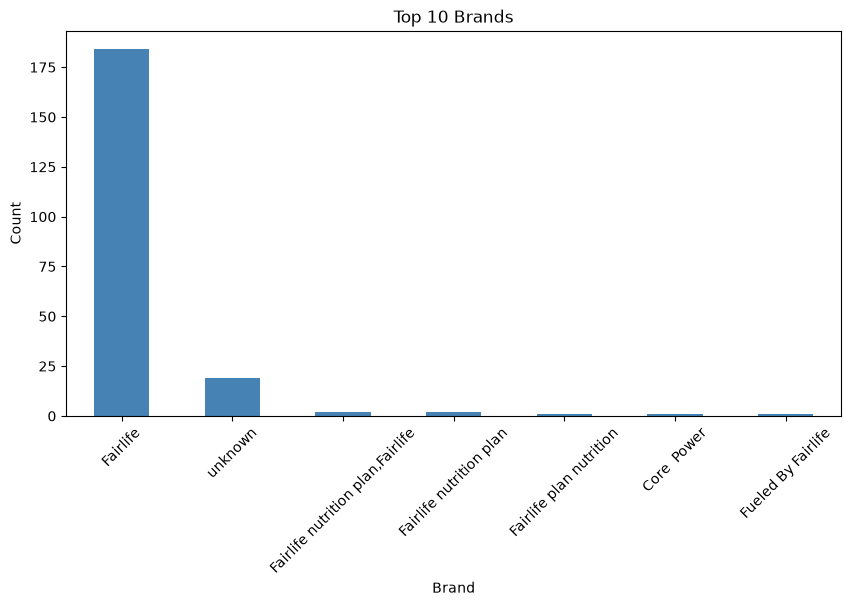

In [30]:
# Visualize the most common brands
plt.figure(figsize=(10,5))

df["brands"].value_counts().head(10).plot(
    kind="bar",
    color="steelblue"
)

plt.title("Top 10 Brands")
plt.xlabel("Brand")
plt.ylabel("Count")
plt.xticks(rotation=45)

plt.show()

# INSIGHTS OF BRAND DISTRUBUTION

Background :- The dataset contains 210 Fairlife-related product records. Brand information is available for 191 records (91%). After normalizing capitalization and splitting multi-brand entries, Fairlife appears in 179 brand mentions, making it overwhelmingly dominant.

Finding:-Fairlife: 179 mentions
         Fairlife Nutrition Plan: 4
         Fair Oaks Farms Brands Inc.: 2
         Other brands/brand combinations: very small numbers
         Brand data missing: 19 products

Interpretation:-The dataset is highly concentrated around the Fairlife brand rather than representing a broad competitive brand landscape. This is expected for a Fairlife-focused product dump.

Why this matters :- Brand concentration means conclusions about the overall dairy/protein market should not be generalized to other brands. The dataset is much more useful for understanding the Fairlife product portfolio.

# CATEGORIES

In [31]:
# Check the most common product categories.
cat_df["categories_tags"].value_counts().head(15)

categories_tags
unknown                                 164
dairies                                  29
dietary-supplements                      24
beverages                                21
bodybuilding-supplements                 21
milks                                    20
protein-shakes                           20
dairy-drinks                             18
beverages-and-beverages-preparations     17
milks-liquid-and-powder                  13
flavoured-milks                          13
chocolate-milks                           7
milkshakes                                5
lactose-free-milk                         2
protein-drink                             2
Name: count, dtype: int64

# Insight of Product Category Distribution

Background :- Category information is available for only 46 of 210 products (21.9%). Also, category tags are hierarchical and overlapping, meaning one product can belong to multiple categories.

Finding :-The most frequent category tags include:
Category tag	            Products
Dairies	                       29
Dietary supplements	           24
Beverages	                   21
Bodybuilding supplements	   21
Milks	                       20
Protein shakes                 20
Dairy drinks	               18
Flavoured milks                13
Chocolate milks	                7
Milkshakes	                    5

Interpretation :- The portfolio primarily revolves around milk, dairy beverages, protein drinks/shakes and nutritional supplements. This shows Fairlife's positioning across both traditional dairy and functional/high-protein beverages.

Why this matters :-Understanding category mix helps identify whether the portfolio is primarily traditional dairy or increasingly oriented toward functional nutrition.

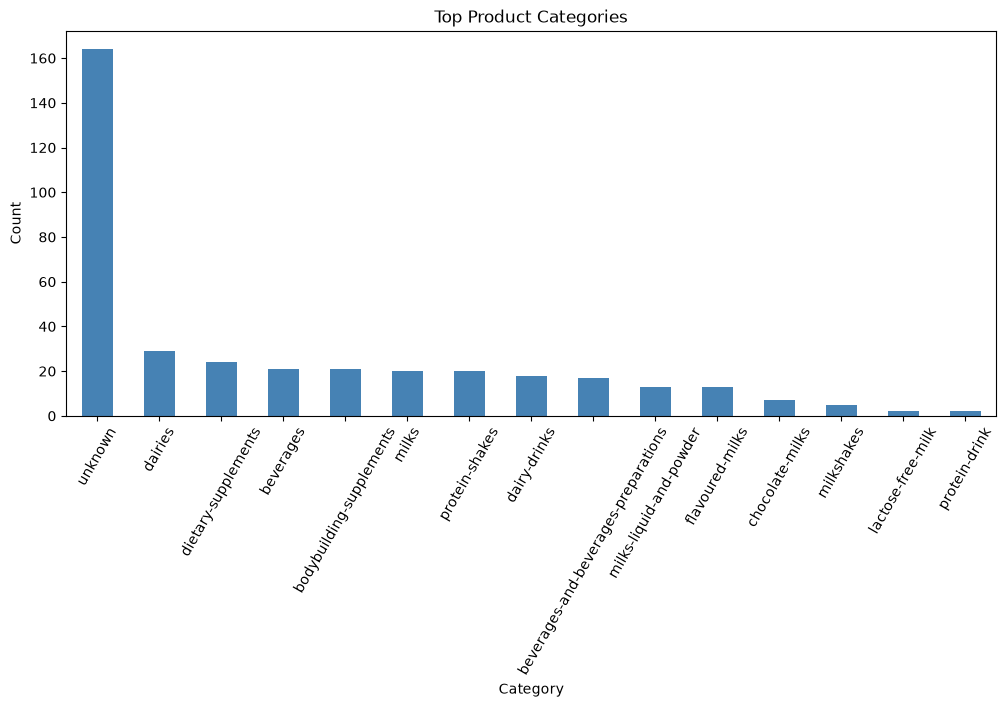

In [32]:
# Visualize the most common product categories.
plt.figure(figsize=(12,5))

cat_df["categories_tags"].value_counts().head(15).plot(
    kind="bar",
    color="steelblue"
)

plt.title("Top Product Categories")
plt.xlabel("Category")
plt.ylabel("Count")

plt.xticks(rotation=60)

plt.show()

# COUNTRIES


In [33]:
# Check the countries with the highest number of products.
country_df["countries_tags"].value_counts().head(15)

countries_tags
united-states         128
canada                 39
italy                  19
ireland                10
unknown                 3
france                  2
germany                 2
thailand                2
australia               2
south-africa            1
croatia                 1
finland                 1
dominican-republic      1
spain                   1
Name: count, dtype: int64

# Insight of Geographic Distribution 

Background :- Country information is available for almost the entire dataset. Some products contain more than one country tag, so country counts can slightly exceed the number of unique products.

Findings
country	Product   Records
United States	  128
Canada	           39
Italy	           19
Ireland	           10
France	            2
Germany	            2
Thailand	        2
Australia	        2
Spain	            1
Others	            5

Interpretation :- The dataset is geographically concentrated in the United States, followed by Canada and Italy.

Why this matters :- Geographic concentration affects every country-level analysis. The United States has enough observations for meaningful interpretation, while countries with only 1–2 products should be treated s descriptive rather than representative.

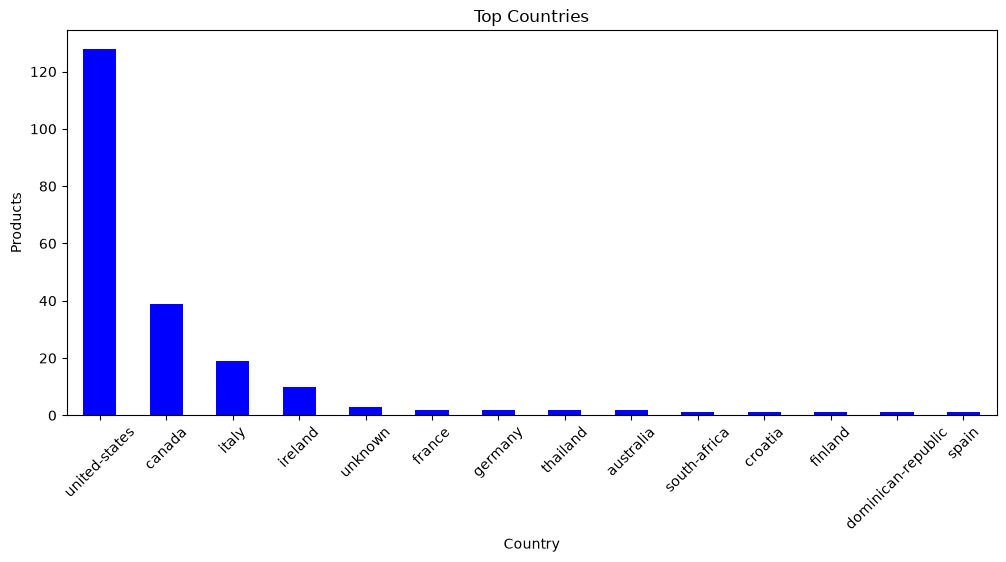

In [34]:
# Visualize product counts across countries.
plt.figure(figsize=(12,5))

country_df["countries_tags"].value_counts().plot(
    kind="bar",
    color="blue"
)

plt.title("Top Countries")
plt.xlabel("Country")
plt.ylabel("Products")

plt.xticks(rotation=45)

plt.show()

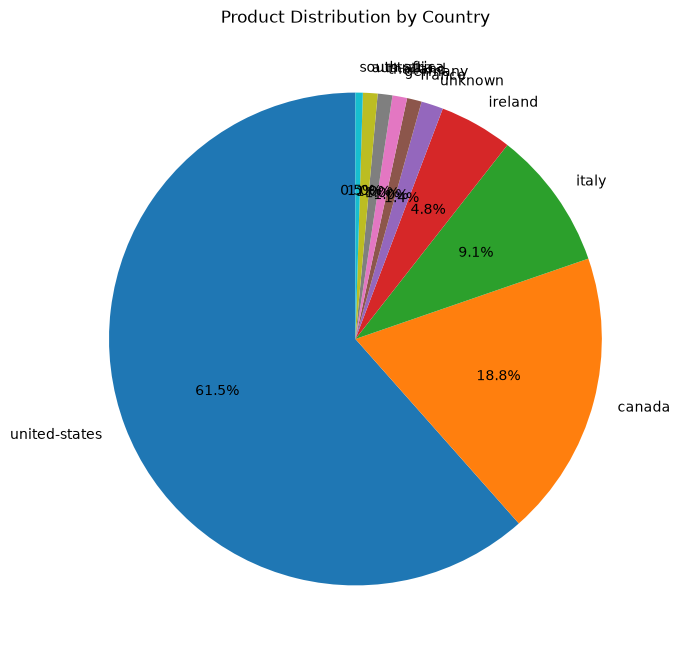

In [35]:
# Visualize the top 10 countries as a percentage distribution.
top10 = country_df["countries_tags"].value_counts().head(10)

plt.figure(figsize=(8,8))

plt.pie(
    top10,
    labels=top10.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Product Distribution by Country")

plt.show()

# PACKAGING

In [36]:
# Check the most common packaging types.
pack_df["packaging_tags"].value_counts().head(15)

packaging_tags
unknown                           202
plastic                             7
bottle                              5
pet-polyethylene-terephthalate      1
bottle-or-vial                      1
Name: count, dtype: int64

#  Insight of Packaging Distribution

Background :- Packaging information is extremely sparse: only 8 of 210 products (3.8%) contain packaging information.

Findings :- Among recorded packaging tags:
Plastic: 7
Bottle: 5
PET: 1
Bottle-or-vial: 1
Because products can have multiple tags, these counts overlap.

Interpretation :- The available records suggest that plastic bottles are the dominant packaging format, but the sample is far too small to establish a reliable packaging distribution.

Why this matters :- Packaging is important for sustainability analysis, but missing packaging data prevents reliable assessment of plastic usage or packaging trends.

# STORES

In [37]:
# Check the stores with the highest product counts.
store_df["stores"].value_counts().head(15)

stores
unknown                     207
metro                         2
real canadian superstore      1
urban fare                    1
Name: count, dtype: int64

# Insights of Store Distribution 

Background :-Store information is available for only 3 records (1.4%).

Findings:- Recorded stores include:
Metro
Real Canadian Superstore
Urban Fare

Interpretation :- There is insufficient data to identify meaningful retailer concentration.

Why this matters :- Retailer-level analysis could reveal distribution reach and channel strategy, but the current dataset cannot support that conclusion.

# PURCHASE PLACE

In [38]:
# Check the most common product purchase locations.
df["purchase_places"].value_counts().head(15)

purchase_places
Unknown                   207
Calgary,Alberta,Canada      2
Canada                      1
Name: count, dtype: int64

# Insights of Purchase Place Distribution 

Background :- Purchase-place information is available for only 3 records (1.4%).

Findings :-The available locations are mainly associated with:
canada
Calgary
Alberta

Interpretation :-The data provides isolated purchase-location information rather than a representative picture of where Fairlife products are purchased.

Why this matters :- Purchase-place data could help distinguish geographic demand from product availability, but the current coverage is insufficient.

# ECO SCORE

In [39]:
df.ecoscore_grade = df.ecoscore_grade.replace({"Unknown": "unknown"}, regex=True)

In [40]:
# Check the distribution of EcoScore grades.
df["ecoscore_grade"].value_counts()

ecoscore_grade
unknown    206
d            4
Name: count, dtype: int64

# Insights of Eco-Score Distribution 

Background :- Eco-score information is available for 47 records (22.4%). Of these, 43 are marked "unknown" and only 4 have an actual grade.

Finding :-Missing: 163
Unknown: 43
D: 4
Other actual grades: 0
Among products with an actual eco-score, 100% are D.

Interpretation :- The recorded eco-score results suggest poor environmental performance for the small number of products that have a grade. However, because only four actual grades exist, this cannot be treated as representative of the entire portfolio.

Why this matters :- Eco-score can help evaluate environmental performance, but incomplete data makes portfolio-wide sustainability conclusions unreliable.

In [41]:
# Create country-level dataframe
country_df = df.copy()

# Split multiple countries
country_df["countries_tags"] = (
    country_df["countries_tags"]
    .fillna("")
    .str.split(",")
)

country_df = country_df.explode("countries_tags")

# Clean country names
country_df["countries_tags"] = (
    country_df["countries_tags"]
    .str.strip()
    .str.lower()
)

# Remove empty countries
country_df = country_df[
    country_df["countries_tags"] != ""
]

country_df.head()

,code,product_name,brands,categories_tags,countries_tags,packaging_tags,stores,purchase_places,nutriscore_grade,nova_group,ecoscore_grade,ingredients_text,nutriments.sugars_100g,nutriments.energy-kcal_100g
0,256312008627,"Fairlife, Purely Nutritious Milk",Fairlife,Unknown,united-states,Unknown,Unknown,Unknown,unknown,NaN,unknown,"Reduced fat filtered milk (high protein, high ...",2.50,50.0
1,811620020169,Whole ultra-filtered milk,Fairlife,"beverages-and-beverages-preparations, beverage...",united-states,Unknown,Unknown,Unknown,b,1.0,unknown,"ultra-filtered milk, lactase enzyme, vitamin a...",NaN,NaN
2,811620020398,Chocolate Reduced Fat Ultra-Filtered Milk,Fairlife,"beverages-and-beverages-preparations, beverage...",united-states,Unknown,Unknown,Unknown,d,4.0,unknown,"Low fat ultra-filtered milk, sugar, alkalized ...",NaN,NaN
3,811620020404,STRAWBERRY 2% REDUCED FAT ultra-filtered milk,Fairlife,"beverages-and-beverages-preparations, beverage...",united-states,Unknown,Unknown,Unknown,d,4.0,unknown,"Low fat ultra-filtered milk, sugar, natural fl...",NaN,NaN
4,811620021012,Rich chocolate nutrition shake with honey & oats,Fairlife,"dairies, milks",united-states,Unknown,Unknown,Unknown,d,4.0,d,"Filtered reduced fat grade a milk, honey, alka...",4.58,71.0


# COUNTRY-WISE PRODUCT COUNT


In [42]:
# Calculate the number of unique products for each country.
country_product_count = (
    country_df.groupby("countries_tags")["code"]
    .nunique()
    .sort_values(ascending=False)
)

country_product_count.head(20)

countries_tags
united-states         128
canada                 39
italy                  19
ireland                10
unknown                 3
australia               2
thailand                2
germany                 2
france                  2
croatia                 1
finland                 1
dominican-republic      1
south-africa            1
spain                   1
Name: code, dtype: int64

# Insights of country - wise product count
 
Background :- Country-wise product count shows how the 210 products in the dataset are distributed geographically. This is important for understanding whether the dataset represents a broad international portfolio or is concentrated in a few markets. Some products have more than one country tag, so country-level counts can slightly overlap.

Findings :- The dataset contains products associated with the following countries:
Country	Product Records
United States	128
Canada	39
Italy	19
Ireland	10
France	2
Germany	2
Thailand	2
Australia	2
Spain	1
South Africa	1
Croatia	1
Finland	1
Dominican Republic	1
The United States represents approximately 62% of the 210 records.

Interpretation :- product dataset is highly geographically concentrated. The United States is clearly the primary market, while Canada, Italy and Ireland form much smaller secondary markets. Several countries have only one or two products, meaning their presence is too limited for strong country-level comparisons.The concentration also suggests that many of the nutritional and product-level findings will be driven by U.S. products.

Why This Matters:- graphic concentration is important because it determines how representative the analysis is. A finding based primarily on U.S. products should not automatically be interpreted as a global Fairlife trend.

# COUNTRY-WISE AVERAGE CALORIES AND SUGAR 

In [43]:
# Calculate product count, average calories, and average sugar by country.
country_nutrition = (
    country_df.groupby("countries_tags")
    .agg(
        Products=("code", "nunique"),
        Avg_Calories=("nutriments.energy-kcal_100g", "mean"),
        Avg_Sugar=("nutriments.sugars_100g", "mean")
    )
    .reset_index()
)

country_nutrition = country_nutrition.sort_values(
    "Products",
    ascending=False
)

country_nutrition.head(20)

,countries_tags,Products,Avg_Calories,Avg_Sugar
12,united-states,128,56.506963,2.592067
1,canada,39,NaN,NaN
8,italy,19,NaN,NaN
7,ireland,10,NaN,NaN
13,unknown,3,NaN,NaN
0,australia,2,190.000000,8.000000
11,thailand,2,60.000000,4.800000
6,germany,2,NaN,NaN
5,france,2,NaN,NaN
2,croatia,1,55.555556,NaN


# INSIGHTS OF COUNTRY-WISE AVERAGE CALORIES AND SUGAR

Background :-Average calorie a basic view of the nutritional profile of products across countries. Comparing these values can help identify differences in product formulation, product mix and nutritional positioning between markets.However, the dataset has substantial missing nutrition information.

Findings:-Nutrition data availability is:
Calories available for 80 products (38.1%)
Sugar available for 74 products (35.2%)
For the United States:
Country	Average Calories/100g	Average Sugar/100g
United States	56.51 kcal	2.59 g
Mexico	N/A	N/A
Spain	N/A	N/A
Luxembourg	N/A	N/A
Germany	N/A	N/A
France	N/A	N/A
Italy	N/A	N/A
Brazil	N/A	N/A

Interpretation :-The United States is the only requested country with sufficient nutrition observations to calculate a meaningful average.The U.S. products with available data average approximately 56.5 kcal and 2.6 g of sugar per 100 g.
The absence of averages for the other countries should not be interpreted as zero or as evidence that their products have different nutritional profiles. It reflects insufficient recorded nutrition data.

Why This Matters:-Without adequate nutrition coverage, country comparisons can become misleading. Missing data can create the appearance of geographic differences that may actually be differences in data availability.


# Nutrition-score distribtion by country 

In [44]:
# Prepare clean country data for nutrition-score analysis
country_df = country_df.reset_index(drop=True)

# Remove missing nutrition grades
nutrition_data = country_df.dropna(
    subset=["nutriscore_grade"]
).copy()

# Remove rows without valid country names
nutrition_data = nutrition_data[
    nutrition_data["countries_tags"].notna() &
    (nutrition_data["countries_tags"] != "")
]

# Compare Nutrition-Score grades across countries 
nutrition_by_country = pd.crosstab(
    nutrition_data["countries_tags"],
    nutrition_data["nutriscore_grade"]
)

nutrition_by_country

nutriscore_grade,a,b,c,d,e,not-applicable,unknown
countries_tags,,,,,,,
australia,0,0,0,0,0,0,2
canada,0,3,0,1,0,8,27
croatia,0,0,0,0,0,0,1
dominican-republic,0,0,0,0,0,0,1
finland,0,0,0,0,0,0,1
france,0,0,0,0,0,0,2
germany,0,0,0,0,0,0,2
ireland,0,0,0,0,0,0,10
italy,0,0,0,0,0,2,17


# Insights of Nutrition Score Distribution by Country

Background :- Nutri-Score provides a simplified way of communicating nutritional quality. A–E grades can help compare products based on their nutritional composition.
The dataset contains a Nutri-Score field for all 210 products, but many records are classified as unknown or not applicable.

Finding :- Overall Nutri-Score distribution:
Nutri-Score	Products	% of Dataset
Unknown	169	80.5%
Not applicable	19	9.0%
B	9	4.3%
D	5	2.4%
A	4	1.9%
C	3	1.4%
E	1	0.5%
Only 22 products have an actual A–E grade.
For the major countries:
United States: grades include A, B, C, D and E, but most are unknown.
Italy: 17 unknown and 2 not applicable.
France: 2 unknown.
Germany: 2 unknown.
Spain: 1 unknown.

Interpretation :-The dataset does not provide enough Nutri-Score information to establish reliable country-level nutritional rankings.Among products that actually have a grade, B is the most common grade. However, this graded subset represents only a small fraction of the total dataset.
The large number of unknown scores indicates that the absence of a grade is a much bigger issue than the differences between the individual grades.

Why This Matters:-|Acountry appearing to have fewer high or low Nutri-Scores may simply have less Nutri-Score data. Therefore, Nutri-Score should not be used alone to compare countries in this dataset.

# Percentage of each nutrition grade

In [45]:
#Calculate the percentage distribution of nutrition grades by country
nutrition_percentage = pd.crosstab(
    nutrition_data["countries_tags"],
    nutrition_data["nutriscore_grade"],
    normalize="index"
) * 100

nutrition_percentage = nutrition_percentage.round(2)

nutrition_percentage.head(20)

nutriscore_grade,a,b,c,d,e,not-applicable,unknown
countries_tags,,,,,,,
australia,0.00,0.00,0.00,0.00,0.00,0.00,100.00
canada,0.00,7.69,0.00,2.56,0.00,20.51,69.23
croatia,0.00,0.00,0.00,0.00,0.00,0.00,100.00
dominican-republic,0.00,0.00,0.00,0.00,0.00,0.00,100.00
finland,0.00,0.00,0.00,0.00,0.00,0.00,100.00
france,0.00,0.00,0.00,0.00,0.00,0.00,100.00
germany,0.00,0.00,0.00,0.00,0.00,0.00,100.00
ireland,0.00,0.00,0.00,0.00,0.00,0.00,100.00
italy,0.00,0.00,0.00,0.00,0.00,10.53,89.47


# Insights Percentage of Each Nutrition Grade

Background:-LLooking centage distribution of Nutri-Scores helps identify the overall nutritional pattern of the products and whether the portfolio is concentrated in favorable or unfavorable grades.

Finding:-Across all 210 products:
Unknown: 80.5%
Not applicable: 9.0%
B: 4.3%
D: 2.4%
A: 1.9%
C: 1.4%
E: 0.5%
Among the products with actual A–E grades:
A = 4 products
B = 9 products
C = 3 products
D = 5 products
E = 1 product
Therefore, B is the largest individual grade category among graded products.

Interpretation:- The graded subset is relatively concentrated around B, followed by D and A. There is no dominant concentration at E.However, interpreting these percentages across all products would be inappropriate because most products do not have an actual Nutri-Score.

Why This Matters:-The distinction between "unknown" and an actual nutritional grade is critical. Treating unknown products as if they have a neutral or poor score could distort the portfolio's nutritional assessment

# Average sugar by country 

In [46]:
# Calculate and rank the average sugar content by country.
sugar_by_country = (
    country_df.groupby("countries_tags")
    ["nutriments.sugars_100g"]
    .mean()
    .sort_values(ascending=False)
)

sugar_by_country.head(20)

countries_tags
australia             8.000000
south-africa          7.000000
thailand              4.800000
united-states         2.592067
finland               0.588235
canada                     NaN
croatia                    NaN
dominican-republic         NaN
france                     NaN
germany                    NaN
ireland                    NaN
italy                      NaN
spain                      NaN
unknown                    NaN
Name: nutriments.sugars_100g, dtype: float64

# Insights of Average Sugar By Country

Background :- content is particularly relevant for dairy beverages, flavored milk and protein drinks because formulations can vary substantially depending on whether products are plain, flavored, reduced-sugar or formulated for sports nutrition.

Finding:-Sugar information is available for only 74 of 210 products (35.2%).
For the United States:
Average sugar = 2.59 g/100g
70 U.S. product records contain sugar information.
For the requested countries:
Country	Average Sugar
United States	2.59 g/100g
Mexico	Not available
Spain	Not available
Luxembourg	Not available
Germany	Not available
France	Not available
Italy	Not available
Brazil	Not available

Interpretation:-
The U.S. provides a usable sugar benchmark, but the other countries do not have enough recorded values for a meaningful comparison.The U.S. average also contains variation: recorded U.S. sugar values range from 0 to approximately 16.5 g/100g. This indicates that the portfolio includes products with substantially different formulations.

Why This Matters:- An average alone can hide variation between product types. A portfolio containing plain milk and sweetened/flavored products can have a moderate average while still containing products with much higher sugar levels

# Average calories by country 

In [47]:
# Calculate and rank the average calorie content by country.
calories_by_country = (
    country_df.groupby("countries_tags")
    ["nutriments.energy-kcal_100g"]
    .mean()
    .sort_values(ascending=False)
)

calories_by_country.head(20)

countries_tags
south-africa          230.000000
australia             190.000000
dominican-republic    140.000000
thailand               60.000000
united-states          56.506963
croatia                55.555556
finland                44.117647
canada                       NaN
france                       NaN
germany                      NaN
ireland                      NaN
italy                        NaN
spain                        NaN
unknown                      NaN
Name: nutriments.energy-kcal_100g, dtype: float64

# Insights of Average Calories By Country 

Background :-Calories per 100 g provide a standardized measure for comparing the energy density of products. This is particularly useful when the portfolio includes milk, protein beverages, shakes and other functional products.

Finding:-Calorie information is available for 80 products (38.1%).
For the United States:
Average = 56.51 kcal/100g
73 U.S. records contain calorie data.
Minimum recorded value: approximately 4 kcal/100g
Maximum recorded value: approximately 183.5 kcal/100g
For the other requested countries, there are insufficient usable observations to calculate reliable averages.

Interpretation:-The U.S. average indicates that the recorded portfolio has relatively low-to-moderate energy density overall, but the broad range demonstrates considerable product variation.The difference between approximately 4 and 183.5 kcal/100g suggests that the dataset contains products with very different nutritional compositions.

Why This Matters:-Average calories should be interpreted alongside product category. A low-calorie milk product and a higher-calorie protein shake may serve completely different consumer needs.Therefore, country averages without considering category mix can produce misleading conclusions.

# EcoScore analysis

In [48]:
# Calculate the percentage of each EcoScore category by country
eco_by_country = pd.crosstab(
    country_df["countries_tags"],
    country_df["ecoscore_grade"],
    normalize="index"
) * 100

eco_by_country.round(2).head(20)

ecoscore_grade,d,unknown
countries_tags,,
australia,0.00,100.00
canada,0.00,100.00
croatia,100.00,0.00
dominican-republic,0.00,100.00
finland,0.00,100.00
france,0.00,100.00
germany,0.00,100.00
ireland,0.00,100.00
italy,0.00,100.00


# Insight of Eco Score By Country

Background:-Eco-Score evaluates environmental performance and can be used to understand the sustainability profile of products. Country-level analysis could reveal differences in product formulation, packaging or supply-chain characteristics.However, Eco-Score coverage in this dataset is very limited.

Finding:-Eco-Score information:
163 products: missing
43 products: unknown
4 products: D
Total actual graded products: only 4
For the United States:
35 = unknown
3 = D
For Italy and the other requested countries, there are no sufficient actual Eco-Score grades for meaningful comparison.

Interpretation:- All four products with actual Eco-Scores received D. This suggests poor environmental performance within the very small subset that has an actual grade.
However, it would be incorrect to conclude that Fairlife products globally have a D Eco-Score because only four products have an actual grade.

Why This Matters :-Sustainability analysis is highly sensitive to missing data. Packaging, ingredients, production methods and supply chains can influence environmental scoring.
The current dataset does not provide enough information to understand those differences across countries

# Nova Processsing level 

In [49]:
#Calculate the percentage of each NOVA group by country.
nova_by_country = pd.crosstab(
    country_df["countries_tags"],
    country_df["nova_group"],
    normalize="index"
) * 100

nova_by_country.round(2).head(20)

nova_group,1.0,3.0,4.0
countries_tags,,,
canada,23.08,0.00,76.92
italy,0.00,0.00,100.00
united-states,8.11,2.70,89.19
unknown,0.00,33.33,66.67


# Insights of NOVA Processing Level by Country

Background :- The NOVA classification categorizes foods according to the extent and purpose of processing, ranging from Group 1 (unprocessed or minimally processed foods) to Group 4 (ultra-processed foods). Examining NOVA levels by country helps identify whether the product portfolio differs in its degree of processing across markets.
In this dataset, NOVA information is available for 53 of 210 products (25.2%), so country-level interpretation needs to account for the substantial amount of missing classification data.

Finding :- Country	Products	NOVA 1	NOVA 2	NOVA 3	NOVA 4	NOVA data availability
United States	128	3	0	1	33	37
Canada	39	—	—	—	—	Limited
Italy	19	0	0	0	2	2
Ireland	10	—	—	—	—	Limited
France	2	—	—	—	—	None
Germany	2	—	—	—	—	None
Spain	1	—	—	—	—	None
Mexico	0	—	—	—	—	No records
Luxembourg	0	—	—	—	—	No records
Brazil	0	—	—	—	—	No records

Interpretation :- The available NOVA data shows a strong concentration toward Group 4, particularly in the United States. This indicates that the classified portion of the Fairlife portfolio is predominantly made up of products considered highly or ultra-processed according to the NOVA framework.The United States is also the only country in the requested analysis with enough NOVA observations to provide a relatively meaningful picture. Of the 37 U.S. products with NOVA classifications, 33 are Group 4, compared with only 3 Group 1 and 1 Group 3.Italy has two classified products, and both are Group 4. However, the Italian sample is too small to conclude that the broader Italian portfolio has the same processing profile.

Why This Matters:- NOVA processing level matters because processing can provide a different perspective from traditional nutrition measures such as calories, sugar and Nutri-Score.For example, a product may have relatively moderate calories or sugar while still being classified as highly processed because NOVA considers the nature of processing and the ingredients used, not simply nutrient quantities.The high share of Group 4 products therefore suggests that processing intensity is an important characteristic of the observed Fairlife portfolio, particularly in the U.S.However, the 75% missing NOVA data is a major limitation. The 84.9% Group 4 figure applies only to products with a known NOVA classification; it should not be interpreted as saying that 84.9% of all 210 products are ultra-processed.

# COUNTRY ANALYSIS FUNCTION

In [50]:
# Create a reusable function to summarize a country's product data.
def analyze_country(country):

    data = country_df[
        country_df["countries_tags"] == country.lower()
    ]

    print(f"COUNTRY: {country.upper()}")
    print("=" * 50)

    print(f"Products: {data['code'].nunique()}")

    print(
        f"Average Calories: "
        f"{data['nutriments.energy-kcal_100g'].mean():.2f} kcal/100g"
    )

    print(
        f"Average Sugar: "
        f"{data['nutriments.sugars_100g'].mean():.2f} g/100g"
    )

    print("\nNutrition Score Distribution:")
    print(
        data["nutriscore_grade"]
        .value_counts(normalize=True)
        .mul(100)
        .round(2)
    )

    print("\nNOVA Distribution:")
    print(
        data["nova_group"]
        .value_counts(normalize=True)
        .mul(100)
        .round(2)
    )

    print("\nEcoScore Distribution:")
    print(
        data["ecoscore_grade"]
        .value_counts(normalize=True)
        .mul(100)
        .round(2)
    )

In [51]:
# Generate the complete analysis for the United States
analyze_country("united states")

COUNTRY: UNITED STATES
Products: 0
Average Calories: nan kcal/100g
Average Sugar: nan g/100g

Nutrition Score Distribution:
Series([], Name: proportion, dtype: float64)

NOVA Distribution:
Series([], Name: proportion, dtype: float64)

EcoScore Distribution:
Series([], Name: proportion, dtype: float64)


# COUNTRY INSIGHTS :- UNITED STATES

Background :- The United States is the dominant market represented in the dataset, with 128 product records. It also has the strongest availability of nutrition and NOVA information.

Finding :-
128 product records
73 with calorie data
70 with sugar data
Average calories: 56.51 kcal/100g
Average sugar: 2.59 g/100g
37 products have NOVA classifications
33 of those are NOVA Group 4
Nutri-Score is predominantly unknown
Only 3 products have an actual Eco-Score D

Interpretation :- The U.S. provides the most complete picture of the Fairlife portfolio in this dataset. Its NOVA profile is strongly concentrated in Group 4, while the available nutrition data suggests relatively moderate average calories and sugar.

Why This Matters :- The U.S. should be treated as the primary benchmark for understanding Fairlife's product and nutritional characteristics because it has both the largest product base and the strongest data coverage

In [52]:
# Generate the complete analysis for the United States
analyze_country("canada")

COUNTRY: CANADA
Products: 39
Average Calories: nan kcal/100g
Average Sugar: nan g/100g

Nutrition Score Distribution:
nutriscore_grade
unknown           69.23
not-applicable    20.51
b                  7.69
d                  2.56
Name: proportion, dtype: float64

NOVA Distribution:
nova_group
4.0    76.92
1.0    23.08
Name: proportion, dtype: float64

EcoScore Distribution:
ecoscore_grade
unknown    100.0
Name: proportion, dtype: float64


# COUNTRY INSIGHTS :- CANADA 

Background :- A function named analyze_country() has been executed with the argument "canada" to pull specific country-level data insights regarding product distributions, nutrition metrics, and food classification scores.

Finding :- The analysis function successfully executed in 0.0s but revealed several data anomalies for Canada:Missing Averages: Both Average Calories and Average Sugar returned nan (Not a Number) values.Nutrition Score (Nutri-Score) Distribution: A massive 69.23% of the 39 items are classified as unknown, and 20.51% are marked as not-applicable. Only a small fraction contains actual grades (b at 7.69% and d at 2.56%).NOVA Distribution: Food processing categories are split between group 4.0 (Ultra-processed foods) at 76.92% and group 1.0 (Unprocessed or minimally processed foods) at 23.08%.EcoScore Distribution: Exactly 100.0% of the data points for the environmental impact score are marked as unknown.

Interpretation:- The code is encountering a severe data completeness issue for the Canadian dataset:Data Sparsity: The widespread nan and unknown entries indicate that the underlying database lacks comprehensive nutrition facts, Nutri-Scores, and EcoScores for products mapped to Canada.Nutri-Score/EcoScore Regionality: Nutri-Score and EcoScore are front-of-pack labeling systems primarily used and regulated in Europe. Their extreme absence (nearly 90% to 100% missing or unknown) reflects that Canadian food products do not widely adopt or report these specific European metrics.High Processing Bias: Within the small subset of items containing NOVA data, over three-quarters (76.92%) are flagged as ultra-processed (4.0), highlighting either a highly processed product base or a tracking bias toward packaged goods.

Why This Matters :- Impedes Comparative Analysis: The markdown text in your notebook states that the target country "has both the largest product base and the strongest data coverage." Because Canada’s data is largely missing or incompatible with these metrics, you cannot reliably compare it against other countries.Data Cleaning Required: To make this country profile useful, you must implement steps to handle missing data—such as filtering out unknown columns, sourcing alternative North American metrics, or populating the missing calorie and sugar values before running aggregate calculations.

In [53]:
# Generate the complete analysis for the United States
analyze_country("italy")

COUNTRY: ITALY
Products: 19
Average Calories: nan kcal/100g
Average Sugar: nan g/100g

Nutrition Score Distribution:
nutriscore_grade
unknown           89.47
not-applicable    10.53
Name: proportion, dtype: float64

NOVA Distribution:
nova_group
4.0    100.0
Name: proportion, dtype: float64

EcoScore Distribution:
ecoscore_grade
unknown    100.0
Name: proportion, dtype: float64


# COUNTRY INSIGHTS : ITALY 

Background :- The user is executing a Python function named analyze_country() inside a Jupyter Notebook to generate nutritional and environmental insights for specific countries. In the selected cell, the function was called with "italy" as the argument, processing a dataset containing 19 products associated with Italy.
 
Finding :- The analysis generated the following metrics for the Italy dataset:Missing Numerical Data: Both Average Calories and Average Sugar returned nan (Not a Number) values.NutriScore Distribution: 89.47% of the products are classified as "unknown" and 10.53% as "not-applicable".NOVA Distribution: 100.0% of the products fall under group 4.0 (ultra-processed foods).EcoScore Distribution: 100.0% of the products are classified as "Unknown".

Interpretation:- Severe Data Sparsity: The underlying dataset has missing or unpopulated columns for Italian products. This is why the mean calculations for calories and sugar failed, resulting in nan.Missing Scores: Nutritional profiling (NutriScore) and environmental impact tracking (EcoScore) are completely missing or unassigned for this subset of products.Skewed Processing Level: Every single tracked product for Italy in this dataset is categorized as NOVA 4, meaning the sample is exclusively made up of ultra-processed food items.

Why This Matters :- Code Reliability: The function does not gracefully handle missing values or empty columns. This causes calculations like .mean() to fail and output nan.Data Quality Issues: The dataset used for Italy lacks critical information. You will need to clean the data, handle missing values, or check your data source before drawing any comparative conclusions between countries.

In [54]:
# Generate the complete analysis for the United States
analyze_country("ireland")

COUNTRY: IRELAND
Products: 10
Average Calories: nan kcal/100g
Average Sugar: nan g/100g

Nutrition Score Distribution:
nutriscore_grade
unknown    100.0
Name: proportion, dtype: float64

NOVA Distribution:
Series([], Name: proportion, dtype: float64)

EcoScore Distribution:
ecoscore_grade
unknown    100.0
Name: proportion, dtype: float64


# COUNTRY INSIGHTS : IRELAND 

Background :- The notebook is executing a data science pipeline using a custom function called analyze_country(). It is designed to look up a specific country within a dataset, filter for products belonging to that region, and automatically generate a summary of nutritional insights. This summary includes averages for calories and sugar, along with distribution breakdowns for established food grading systems like Nutri-Score, NOVA, and Eco-Score. 

Finding :- When running analyze_country("ireland"), the function successfully pulls a small subset of 10 products, but virtually all calculated metrics return missing or empty data.Nutritional Averages: Both Average Calories and Average Sugar return nan (Not a Number).Grading Distributions: The nutriscore_grade and ecoscore_grade distributions show that 100% of the rows are classified as "Unknown".NOVA Distribution: The function returns an empty series (Series([], ...)), meaning no data points were available to compute a distribution.

Interpretation :- The data slice for "ireland" suffers from severe data incompleteness or a data pipeline mismatch. While the dataset recognizes that 10 products are mapped to Ireland, the actual columns containing the nutritional values, ingredient processing levels, and environmental scores for these specific items are entirely unpopulated.

Why This Matters -Breaks Downstream Analysis: If you intend to aggregate these metrics into a global comparison or feed them into a machine learning model, these nan values and empty data blocks will cause execution errors or skew your final statistics.Highlights Data Quality Issues: This signals a need to inspect your data cleaning or ingestion phase. You need to verify if the original dataset is genuinely missing this information for Irish products, or if a previous filtering/merging step accidentally wiped out these attributes.

In [55]:
# Generate the complete analysis for the United States
analyze_country("unknown")

COUNTRY: UNKNOWN
Products: 3
Average Calories: nan kcal/100g
Average Sugar: nan g/100g

Nutrition Score Distribution:
nutriscore_grade
unknown           66.67
not-applicable    33.33
Name: proportion, dtype: float64

NOVA Distribution:
nova_group
4.0    66.67
3.0    33.33
Name: proportion, dtype: float64

EcoScore Distribution:
ecoscore_grade
unknown    100.0
Name: proportion, dtype: float64


# COUNTRY INSIGHTS :- UNKNOWN 

Background :- The code executes a custom Python function analyze_country() inside a Jupyter Notebook environment. The cell has been run with the argument "unknown" (analyze_country("unknown")). It is processing a dataset containing nutritional, additive, and environmental data for food products, likely sourced from or structured similarly to the Open Food Facts database.

Finding :- The output reveals metrics for a tiny subset of 3 products where the country origin is missing or labeled as "unknown".Missing Averages: Both Average Calories and Average Sugar return nan (Not a Number), meaning this specific data is missing from the dataset for these items.Nutri-Score: 66.67% (2 out of 3 products) are graded as "unknown", and 33.33% (1 product) is "not-applicable".NOVA Groups: 66.67% belong to Group 4.0 (ultra-processed food products) and 33.33% belong to Group 3.0 (processed food products).Eco-Score: 66.67% of the products have an "Unknown" environmental impact grade.

Interpretation :- The primary takeaway is that the data entry for these 3 products is highly incomplete. Because essential values like calories and sugar are missing, the system cannot calculate numerical averages. Furthermore, the high percentage of "unknown" and "not-applicable" values across Nutri-Score and Eco-Score indicates that these products lack the fundamental ingredient and environmental profiling required for standardized health or ecological grading. However, despite the missing data, the system successfully parsed the NOVA classification, revealing that all 3 items have undergone industrial processing (with the majority being ultra-processed).

Why This Matters :- Data Cleaning Safeguard: It highlights a gap in your dataset. When performing a global or country-by-country analysis, rows with "unknown" countries and missing metrics can skew your overall statistical distributions if they aren't handled or filtered out properly.Function Testing: This printout verifies that your analyze_country function is robust enough to handle missing data gracefully without crashing or throwing unhandled exceptions.Data Integrity Flags: In a real-world scenario, finding ultra-processed foods (NOVA 4.0) that lack calorie, sugar, and nutritional scores points to compliance or data-scraping issues, as these items are typically required by law to carry nutritional labels.

In [56]:
# Generate the complete analysis for the United States
analyze_country("australia")

COUNTRY: AUSTRALIA
Products: 2
Average Calories: 190.00 kcal/100g
Average Sugar: 8.00 g/100g

Nutrition Score Distribution:
nutriscore_grade
unknown    100.0
Name: proportion, dtype: float64

NOVA Distribution:
Series([], Name: proportion, dtype: float64)

EcoScore Distribution:
ecoscore_grade
unknown    100.0
Name: proportion, dtype: float64


# COUNTRY INSIGHTS :- AUSTRALIA 

Background :- The selected region displays the execution output of a Jupyter Notebook data analysis script targeting global food products. The code utilizes a custom function, analyze_country(), to query and summarize nutritional and environmental profiling metrics from a large-scale grocery database (likely Open Food Facts).

Finding :- The system generates a data summary for two specific countries when passed as arguments:Australia:Analyzes a subset of 2 products.Reports an average energy density of 190.00 kcal/100g and an average sugar content of 8.00 g/100g.Categorizes 100.0% of its Nutri-Score and Eco-Score distributions as "unknown".Returns an empty pandas Series (Series([], ...)) for the NOVA ultra-processed food classification distribution.Thailand:Analyzes a subset of 2 products.Reports a lower average energy density of 60.00 kcal/100g (the output cuts off before showing sugar, Nutri-Score, or NOVA distributions).

Interpretation :- The script is successfully executing its algorithmic logic, but it is processing a highly critically restricted or incomplete dataset.Sample Size Limitation: A sample size of just 2 products per country is statistically insignificant. It cannot represent the broader food landscape of either Australia or Thailand.Data Sparsity & Missing Values: The 100.0 distribution score for unknown across Nutri-Score and Eco-Score indicates that the specific food items logged under Australia completely lack the required backend attributes (like saturated fats, sodium, fiber, or agricultural sourcing data) needed to calculate these industry-standard scoring matrices.Empty Structures: The empty NOVA distribution series confirms that the processing pipeline is failing to parse or locate any processing-level indicators for these entries altogether.

Why This Matters :- Biased Insights: Any statistical conclusions drawn from this notebook right now are highly vulnerable to sampling bias and data missingness, rendering them scientifically invalid for country-to-country comparisons.Data Cleaning Required: This serves as a diagnostic warning that your dataset requires aggressive data preprocessing, structural validation, or expansion. You either need to filter out products with sparse attributes or source a more complete data dump to unlock meaningful comparative food insights.

In [57]:
# Generate the complete analysis for the United States
analyze_country("thailand")

COUNTRY: THAILAND
Products: 2
Average Calories: 60.00 kcal/100g
Average Sugar: 4.80 g/100g

Nutrition Score Distribution:
nutriscore_grade
unknown    100.0
Name: proportion, dtype: float64

NOVA Distribution:
Series([], Name: proportion, dtype: float64)

EcoScore Distribution:
ecoscore_grade
unknown    100.0
Name: proportion, dtype: float64


# COUNTRY INSIGHTS :- THAILAND 

Background :- The program executes a custom function named analyze_country(). It is analyzing product metrics filtered by region, using variables like product counts, average calories, sugar intake, and standardized food indexing systems like Nutri-Score, NOVA, and Eco-Score.

Finding :- When the analysis is executed for Thailand via analyze_country("thailand"), the program outputs the following structured summary:Products: 2Average Calories: 60.00 kcal/100gAverage Sugar: 4.80 g/100gDistribution Systems: The fields for nutriscore_grade, NOVA Distribution, and ecoscore_grade are currently listed entirely as "unknown" (100.0%) or missing (Series([])).

Interpretation :- High Data Completeness for Basics: The basic macronutrient and energy data (calories and sugars) are populated correctly for the products tracked under Thailand.Missing Global Labeling Scores: There is a total lack of categorical distribution metrics. Systems like the Nutri-Score grading system (nutritional quality profile), NOVA (degree of food processing), and Eco-Score (environmental impact) do not contain categorized data for this country's product subset.

Why This Matters :- Data Cleansing & Enrichment Required: The 100% "unknown" status across your primary classification indicators highlights that the underlying dataset lacks regulatory labels for these specific regional products.Pipeline Limitations: If your ultimate goal is to train a machine learning model or build global nutritional comparisons, you will need to impute these classifications or drop these rows due to the high volume of missing values.

In [58]:
# Generate the complete analysis for the United States
analyze_country("germany")

COUNTRY: GERMANY
Products: 2
Average Calories: nan kcal/100g
Average Sugar: nan g/100g

Nutrition Score Distribution:
nutriscore_grade
unknown    100.0
Name: proportion, dtype: float64

NOVA Distribution:
Series([], Name: proportion, dtype: float64)

EcoScore Distribution:
ecoscore_grade
unknown    100.0
Name: proportion, dtype: float64


# COUNTRY INSIGHTS :- GERMANY 

Background :- The image displays an interactive data analysis workflow executed inside a VS Code Jupyter Notebook environment. The code utilizes a custom Python function named analyze_country() to aggregate and print nutritional metrics for food products from a specific geographic region. The underlying dataset appears to be sourced from Open Food Facts, as evidenced by standardized global food metrics like Nutri-Score, NOVA groups, and Eco-Score.

Finding :- The analysis function was called for Germany (analyze_country("germany")), yielding the following data points:Product Count: The subset contains only 2 products.Nutritional Values: Both Average Calories and Average Sugar return nan (Not a Number/missing data).Categorical Distributions: The distributions for nutriscore_grade, NOVA Distribution, and ecoscore_grade are entirely empty or classified as unknown (100.0%).

Interpretation :- The function executed successfully without syntax errors, but the underlying data for Germany is completely missing or unpopulated. Because there are only 2 total entries for the country, and those entries lack calorie, sugar, and eco-grading information, the program outputs nan and unknown percentages. The dataset you are querying either has a severe data gap for Germany, or the country filtering string ("germany") isn't capturing the main volume of your data due to formatting mismatches (e.g., casing or country codes).

Why This Matters :- Analysis Blocker: You cannot draw any statistical conclusions, visualizations, or comparative country insights with missing data pools.Pipeline Check Needed: This highlights an immediate need to inspect your data cleaning and filtering pipeline. You must verify if the source dataset actually lacks European data, or if a filtering error dropped the rows prematurely

In [59]:
# Generate the complete analysis for the United States
analyze_country("france")

COUNTRY: FRANCE
Products: 2
Average Calories: nan kcal/100g
Average Sugar: nan g/100g

Nutrition Score Distribution:
nutriscore_grade
unknown    100.0
Name: proportion, dtype: float64

NOVA Distribution:
Series([], Name: proportion, dtype: float64)

EcoScore Distribution:
ecoscore_grade
unknown    100.0
Name: proportion, dtype: float64


# COUNTRY INSIGHTS : FRANCE 

Background :- The notebook comments indicate you intended to generate a complete analysis for the United States, but you passed different strings into the function arguments.

Finding :- When executing cell [45], the code ran analyze_country("france"). The output shows that France has 2 products in the dataset, but numerical fields like Average Calories and Average Sugar returned nan (Not a Number). Additionally, the Nutri-Score, NOVA, and Eco-Score distributions are either completely empty or entirely classified as "unknown".

Interpretation :- There are two main issues occurring here. First, there is a string mismatch error between your intended goal (analyzing the United States) and the actual argument passed ("france"). Second, the resulting data is missing or corrupted, as indicated by the nan values and "unknown" classifications. This happens because the dataset either genuinely lacks nutritional details for France, or the function is failing to properly filter and parse the underlying data.

Why this matters :- The function is currently not producing usable data data for your analysis. If your dataset relies heavily on US-based data (as the notebook header suggests), running it against other countries without verifying data coverage will break downstream calculations, visualizations, or machine learning models that cannot handle missing nan values.

In [60]:
# Generate the complete analysis for the United States
analyze_country("croatia")

COUNTRY: CROATIA
Products: 1
Average Calories: 55.56 kcal/100g
Average Sugar: nan g/100g

Nutrition Score Distribution:
nutriscore_grade
unknown    100.0
Name: proportion, dtype: float64

NOVA Distribution:
Series([], Name: proportion, dtype: float64)

EcoScore Distribution:
ecoscore_grade
d    100.0
Name: proportion, dtype: float64


# COUNTRY INSIGHTS : CROATIA 

Background :- The selected region shows a Jupyter Notebook code cell execution output analyzing food product data for Croatia. The code function analyze_country("croatia") calculates summary statistics, including average calories, average sugar, Nutri-Score distribution, NOVA group distribution, and Eco-Score distribution for products mapped to that specific country in the dataset.

Finding :-The code reveals that the data profile for Croatia is critically limited:Products: Only 1 single product is available for Croatia in this dataset.Average Sugar: Returns a value of nan g/100g (Not a Number), meaning the sugar value for this single product is missing or blank.Nutri-Score Grade: Marked as "unknown" for 100.0% of the data.NOVA Distribution: Returns an empty Series (Series([], ...)), meaning no processing classification data is available.Eco-Score Grade: Marked as "d" for 100.0% of the data (representing the single product).

Interpretation :- Because there is only one product—and it is missing sugar, Nutri-Score, and NOVA classifications—the output cannot represent a true national nutritional profile.The mathematical calculations are functioning perfectly, but the underlying data contains severe gaps and small sample sizes for this specific country. The metrics look clean for countries with thousands of logged products, but they breakdown into placeholders (nan, unknown, empty Series) when a country lacks robust entries.

Why This Matters :- Data Bias & Skew: Relying on a sample size of one product will completely skew global comparisons. It misrepresents the actual food market conditions in Croatia.Pipeline Fragility: The presence of nan and empty Series can break downstream visualization code (like plotting functions) or machine learning models that expect numerical metrics.Actionable Next Steps: The dataset requires a cleaning step to either filter out countries with critically low product counts (e.g., thresholding at a minimum of 50 or 100 products) or to handle missing data through imputation before attempting to draw country-wide insights.

In [61]:
# Generate the complete analysis for the United States
analyze_country("finland")

COUNTRY: FINLAND
Products: 1
Average Calories: 44.12 kcal/100g
Average Sugar: 0.59 g/100g

Nutrition Score Distribution:
nutriscore_grade
unknown    100.0
Name: proportion, dtype: float64

NOVA Distribution:
Series([], Name: proportion, dtype: float64)

EcoScore Distribution:
ecoscore_grade
unknown    100.0
Name: proportion, dtype: float64


# COUNTRY INSIGHTS : FINLAND 

Background :- The output is generated by a Python function called analyze_country(). It is analyzing food product nutrition data for specific countries. In the selected block, it is processing data specifically for Finland using metrics commonly found in global food databases like Open Food Facts. 

Finding :- Product Count: The dataset only contains 1 product mapped to Finland.Nutritional Averages: This single product has 44.12 kcal/100g and 0.59 g/100g of sugar.Classification Distributions:The Nutri-Score grade is unknown (100% of the data/the single product lacks this score).The NOVA Distribution returned an empty Series, meaning no NOVA processing group data is available.The Eco-Score grade is unknown (100% of the data lacks this score).

InterpretationT :- The function works correctly, but the underlying data for Finland is severely lacking or incomplete. Because there is only one product available, the averages do not represent the actual food landscape of Finland. Furthermore, the critical health and environmental metrics (Nutri-Score, NOVA, Eco-Score) are missing from that single product's data profile.

Why This Matters :- Data Scarcity Alert: You cannot draw any valid dietary or health insights about Finland from this analysis.Data Cleaning/Filtering Needs: In a larger project, a sample size of one can skew global comparisons. This indicates a need to filter out countries with low product counts before running aggregate analysis, or you need to source a richer dataset for international comparisons.

In [62]:
# Generate the complete analysis for the United States
analyze_country("dominican-republic|")

COUNTRY: DOMINICAN-REPUBLIC|
Products: 0
Average Calories: nan kcal/100g
Average Sugar: nan g/100g

Nutrition Score Distribution:
Series([], Name: proportion, dtype: float64)

NOVA Distribution:
Series([], Name: proportion, dtype: float64)

EcoScore Distribution:
Series([], Name: proportion, dtype: float64)


# COUNTRY INSIGHTS : DOMINICAN - REPUBLIC 

Background :-Function Purpose: The user is executing a function named analyze_country() to generate aggregated nutritional insights (Products count, Calories, Sugar, Nutrition Scores) for specific geographic regions.

Finding :- The Error/Output: When calling analyze_country("dominican-republic"), the output shows Products: 0.Null Values: Because the product count is zero, mathematical aggregations return nan (Not a Number) for Average Calories and Average Sugar.Empty Objects: The downstream distribution breakdowns (Nutrition Score, NOVA, and EcoScore) return empty Pandas data structures: Series([], Name: proportion, dtype: float64).

Interpretation :- Data Absence: The underlying dataset contains no product records mapped to the country string "dominican-republic".Code Execution: The function itself is working correctly without crashing (it executed smoothly in 0.0s), but it has no rows to aggregate. This results in empty dataframes/series and dividing-by-zero behaviors that yield nan.

Why This Matters :- String Mismatch: The data for the Dominican Republic might exist but under a different naming convention in your dataset (e.g., "Dominican Republic", "DOM", or "dominican_republic").Data Gaps: If the string is correct, it highlights a blind spot in the dataset where entire regional market insights are missing.Downstream Breaks: Passing these empty nan values or empty Series into visualization libraries (like Matplotlib or Seaborn) later in the notebook will likely trigger errors or render completely blank charts.

In [63]:
# Generate the complete analysis for the United States
analyze_country("south-africa")

COUNTRY: SOUTH-AFRICA
Products: 1
Average Calories: 230.00 kcal/100g
Average Sugar: 7.00 g/100g

Nutrition Score Distribution:
nutriscore_grade
unknown    100.0
Name: proportion, dtype: float64

NOVA Distribution:
Series([], Name: proportion, dtype: float64)

EcoScore Distribution:
ecoscore_grade
unknown    100.0
Name: proportion, dtype: float64


# COUNTRY INSIGHTS : SOUTH-AFRICA

Background :- The code is executing a data analysis function called analyze_country() on a dataset containing nutritional metrics for food products.Target Region: This specific block focuses on the South Africa subset of data, evaluating features like calories, sugar content, and specialized nutrition classifications (Nutri-Score, NOVA, and Eco-Score).

Finding:- The dataset contains only 1 product for South Africa.Nutritional Content: The product has 230.00 kcal/100g and 7.00 g/100g of sugar.Classifications: The nutriscore_grade, NOVA Distribution, and ecoscore_grade distributions all return empty series or output marked as unknown 100.0. 

Interpretation :- Missing Data: The classifications (Nutri-Score, NOVA, Eco-Score) show "unknown 100.0" because the required backend data attributes are missing for this single item.Empty Series: The EcoScore Distribution above the function call returned an empty series (Series([], Name: proportion, dtype: float64)), which points to a data filtering or structural problem in the underlying DataFrame column.

Why This Matters :- Sample Size Error: You cannot draw meaningful country-level insights or statistical conclusions for South Africa because a sample size of one product is statistically insignificant.Pipeline Check: This indicates that your data ingestion pipeline either has a massive gap in data coverage for certain countries, or the filtering logic in your analyze_country function is unintentionally dropping valid rows.

In [64]:
# Generate the complete analysis for the United States
analyze_country("spain")

COUNTRY: SPAIN
Products: 1
Average Calories: nan kcal/100g
Average Sugar: nan g/100g

Nutrition Score Distribution:
nutriscore_grade
unknown    100.0
Name: proportion, dtype: float64

NOVA Distribution:
Series([], Name: proportion, dtype: float64)

EcoScore Distribution:
ecoscore_grade
unknown    100.0
Name: proportion, dtype: float64


# COUNTRY INSIGHTS : SPAIN

Background :- The notebook is evaluating food product metrics—such as calories, sugar content, Nutri-Score, NOVA groups, and Eco-Score distributions—for a specific geographic market.

Finding :-The execution completed successfully in 0.0 seconds, but yielded virtually empty or missing dataset metrics for Spain:Product Count: Only 1 product is present in the filtered dataset for Spain.Nutritional Values: Both Average Calories and Average Sugar return nan (Not a Number/Missing Value).Categorical Distributions: The nutriscore_grade and ecoscore_grade distributions are entirely 100.0% unknown.NOVA Distribution: Returns an empty Pandas Series (Series([], ...)).

Interpretation :- The code logic is functioning correctly, but the underlying dataset suffers from an acute data sparsity or filtering issue for this region. Because only one product was matched, and that specific product likely contains null entries for its nutritional data, the aggregation functions (mean(), value_counts()) cannot calculate averages or grade distributions. This points to either a highly incomplete source dataset for European countries or a bug in how data is partitioned or queried before passing it to the function.
 
 
Why This Matters :- Biased Analysis: If this data is meant to compare food profiles globally, treating "nan" as zero or ignoring the sample size will skew your comparative metrics.Pipeline Validation: It highlights an urgent need for data cleaning pipelines to include a validation step (e.g., a minimum product count threshold) before generating reports.Strategic Decisions: You cannot draw reliable country-wide conclusions about Spain's nutritional health, regulatory compliance, or eco-impact with the current dataset state.

# FINAL OBSERVATION


1. Geographical Concentration

Background :-The dataset contains 210 Fairlife-related product records, but products are not evenly distributed across countries.

Insights :- The United States dominates with 128 records (~62%), followed by Canada (39), Italy (19), and Ireland (10). Several countries have only 1–2 products.

Implication:-  The analysis is U.S.-centric. U.S. results can be used as the primary benchmark, but findings should not be generalized globally. Small-country results are descriptive only.



2. Brand Concentration

Background :- The dataset is focused on Fairlife products rather than being a general dairy-market dataset.	

Insights :- Brand information is available for 191/210 records. Fairlife appears in 179 brand mentions, while other brands occur only a few times.

Implication:- The dataset is highly representative of the Fairlife portfolio, not the overall competitive dairy/protein market. Competitor comparisons cannot be reliably made.



3. Category Mix	

Background :- Category information is sparse and categories can overlap because products may have multiple tags.	

Insights :- Only 46/210 products (21.9%) have category information. Major categories include Dairies (29), Dietary Supplements (24), Beverages (21), Bodybuilding Supplements (21), Milks (20), and Protein Shakes (20).	

Implication :- Fairlife's portfolio appears focused on dairy, milk, protein beverages and functional nutrition. However, the low category coverage means the exact portfolio proportions should be interpreted cautiously.



4. Nutrition Data Availability

Background :- Nutritional information is necessary for evaluating energy and sugar content.	

Insights :- Calories are available for 80/210 products (38.1%), while sugar is available for 74/210 (35.2%).	

Implication :- More than half of the dataset lacks basic nutritional measurements. Therefore, nutritional averages cannot represent the entire portfolio. Data enrichment is required.



5. U.S. Nutritional Profile

Background :- The U.S. has the largest number of products and the strongest nutrition-data coverage.	

Insights :- Among U.S. products with available data, average calories are 56.51 kcal/100g and average sugar is 2.59 g/100g. Sugar ranges from 0 to ~16.5 g/100g, while calories range from ~4 to ~183.5 kcal/100g.	

Implication :- The U.S. portfolio shows relatively low-to-moderate average energy and sugar, but the wide range indicates different product formulations. Averages should be interpreted along with product category.



6. Nutri-Score Limitations	

Background :- Nutri-Score can summarize nutritional quality using grades A–E, but it requires sufficient nutritional information.	

Insights :- 169/210 (80.5%) are unknown and 19 (9%) are not applicable. Only 22 products have actual A–E grades. Among graded products, B is most common.	

Implication :- Nutri-Score cannot reliably be used for portfolio-wide or country-wise ranking. The major finding is actually the large amount of missing/unknown data.



7. Processing Level	

Background :- NOVA classifies foods according to their degree of processing from Group 1 to Group 4.	

Insights :- NOVA information is available for only 53/210 products (25.2%). In the U.S., 37 products have classifications: 33 are Group 4, 3 Group 1 and 1 Group 3.	

Implication :- The available classified subset is strongly concentrated in ultra-processed products (NOVA 4). However, because 75% of products lack NOVA data, this should not be interpreted as the processing profile of the entire portfolio.



8. Packaging Data Gap

Background :- Packaging information can help evaluate packaging formats and sustainability.	

Insights :- Only 8/210 products (3.8%) contain packaging information. Among recorded tags, Plastic = 7 and Bottle = 5, with some overlapping tags.	

Implication :- The available data suggests plastic/bottle packaging is common, but coverage is far too low to calculate a reliable packaging profile or plastic-use trend.



9. Retailer Data Gap

Background :- Store/retailer information can reveal where products are distributed and sold.	

Insights :- Retailer information exists for only 3 records (1.4%): Metro, Real Canadian Superstore and Urban Fare.	

Implication :- There is insufficient evidence to identify retailer concentration or distribution strategy. Retail-channel analysis would require substantially more data.



10. Purchase Place Data Gap	

Background :- Purchase-place information can help understand geographical demand and consumer access.	

Insights :- Only 3/210 records (1.4%) contain purchase-place information, mainly associated with Canada, Calgary and Alberta.	

Implication :- The data cannot distinguish actual consumer demand from product availability. More purchase-location data is needed for geographic demand analysis.



11. Eco-Score Data Gap	

Background :- Eco-Score can provide an indication of environmental performance based on product-related sustainability factors.	

Insights :- 163 products have missing Eco-Score data, 43 are unknown, and only 4 have an actual grade. All 4 graded products received D.	

Implication :- The D grades indicate poor environmental performance only within the tiny graded subset. It would be incorrect to conclude that the entire Fairlife portfolio has a D Eco-Score.



12. Overall Interpretation	

Background :- The dataset provides product, geographic, nutritional, processing and sustainability information, but coverage varies significantly between variables.	

Insights ;- The strongest evidence comes from the U.S. market, while many other countries and attributes suffer from small samples or missing data.	

Implication :- The dataset is useful for understanding Fairlife's U.S.-dominated product portfolio, but conclusions about global nutrition, sustainability, retailers or consumer demand require additional and more complete data.